I used a initialized a conda env of python 3.11 for this.

### homography of tilted picture (auto全能扫描王)

input: a rectable .jpg that include a tilted picture
output: a rectable .jpg that include a trimed and clear picture

- relavent [h, w] of the .jpg does not matter.
- u will likely using some openCV libraries. write them in the requirement.txt if used.
- write all used functions inside homograohy.py
- follow below struture so that we can manage easily.
- if we tried on a lot of cases and it looks good, then we satisfy.

In [1]:
# img = path to img "xxx.jpg"
# process function 1
# process function 2
# (show img, visualize if needed)
# process function 3
# show final jpg


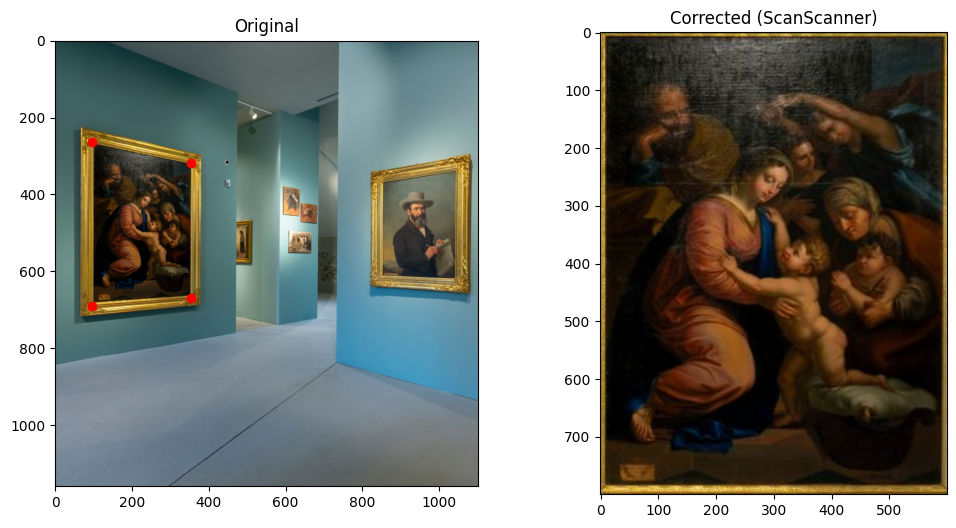

In [ ]:
""""test for v0.1"""
import cv2
import numpy as np
import matplotlib.pyplot as plt
import homography  # Importing the file you just wrote

# 1. Load your test image
img_path = 'test_image.jpg' 
img = cv2.imread(img_path)

# OpenCV loads images in BGR format by default; convert to RGB for correct display in Matplotlib
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 

# 2. Define the four corner coordinates [Top-Left, Top-Right, Bottom-Right, Bottom-Left] (x, y)
# These are placeholder coordinates. Once the image displays, 
# you can use the axis values to fine-tune these points!
src_points = [
    [95, 264],   # Top-Left
    [355, 318],  # Top-Right
    [355, 670],  # Bottom-Right
    [95, 690]    # Bottom-Left
]

# 3. Call the transformation function from homography.py
# Note: Ensure scan_correction converts src_points to float32 internally as required by OpenCV
corrected_img = homography.scan_correction(img, src_points)

# 4. Display the comparison
plt.figure(figsize=(12, 6))

# Plot the Original Image
plt.subplot(1, 2, 1)
plt.title('Original Image (with selected points)')
plt.imshow(img)

# Mark the selected four points with red dots to make manual fine-tuning easier
for pt in src_points:
    plt.plot(pt[0], pt[1], 'ro') 

# Plot the Corrected (Deskewed) Image
plt.subplot(1, 2, 2)
plt.title('Corrected Result (Perspective Warp)')
plt.imshow(corrected_img)

plt.show()

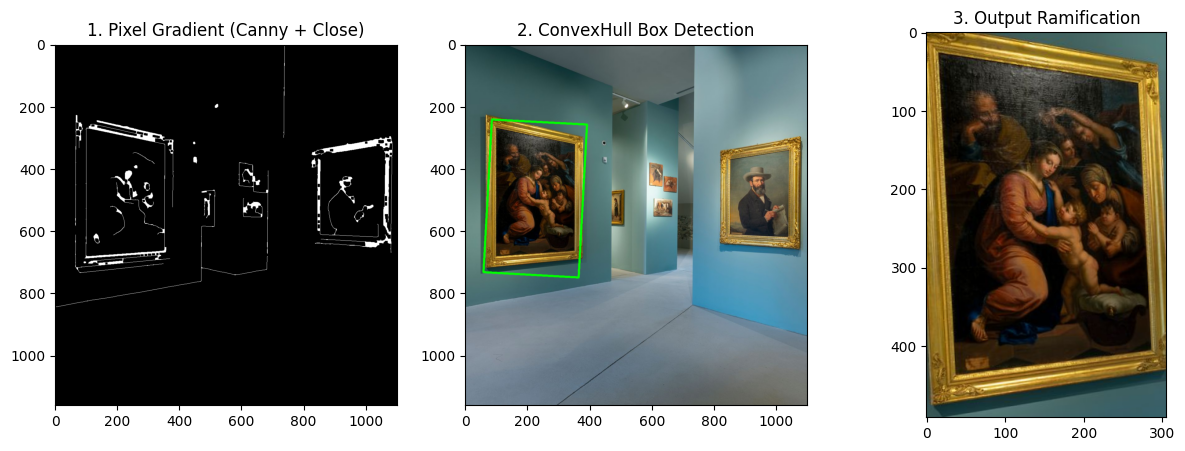

处理完成！最终矩形画作已保存为 output_painting.jpg


In [ ]:
"""Test for v1.0, recognizing the rectangular single painting"""
import cv2
import matplotlib.pyplot as plt
import homography

# Define input and output paths
input_img = 'test_image.jpg'
output_img = 'output_painting.jpg'

# Adjust these values to handle Pixel Gradients under different lighting conditions.
# If there is too much edge noise, increase these values.
# If the border cannot be found, decrease these values.
th1, th2 = 50, 150 

result = homography.auto_detect_and_warp(input_img, output_img, th1, th2)

if result is not None:
    warped, edged, box = result
    orig = cv2.imread(input_img)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    warped = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)
    
    # Draw the detected green bounding box on the original image
    cv2.drawContours(orig, [box], -1, (0, 255, 0), 5)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("1. Pixel Gradient (Canny + Close)")
    plt.imshow(edged, cmap='gray')
    
    plt.subplot(1, 3, 2)
    plt.title("2. ConvexHull Box Detection")
    plt.imshow(orig)
    
    plt.subplot(1, 3, 3)
    plt.title("3. Output Ramification")
    plt.imshow(warped)
    
    plt.show()
    print(f"Processing complete! The final rectangular painting is saved as {output_img}")
else:
    print("Extraction failed. Please try adjusting the gradient_thresh parameters.")

🎉 破案了！成功识别到了 2 幅画！


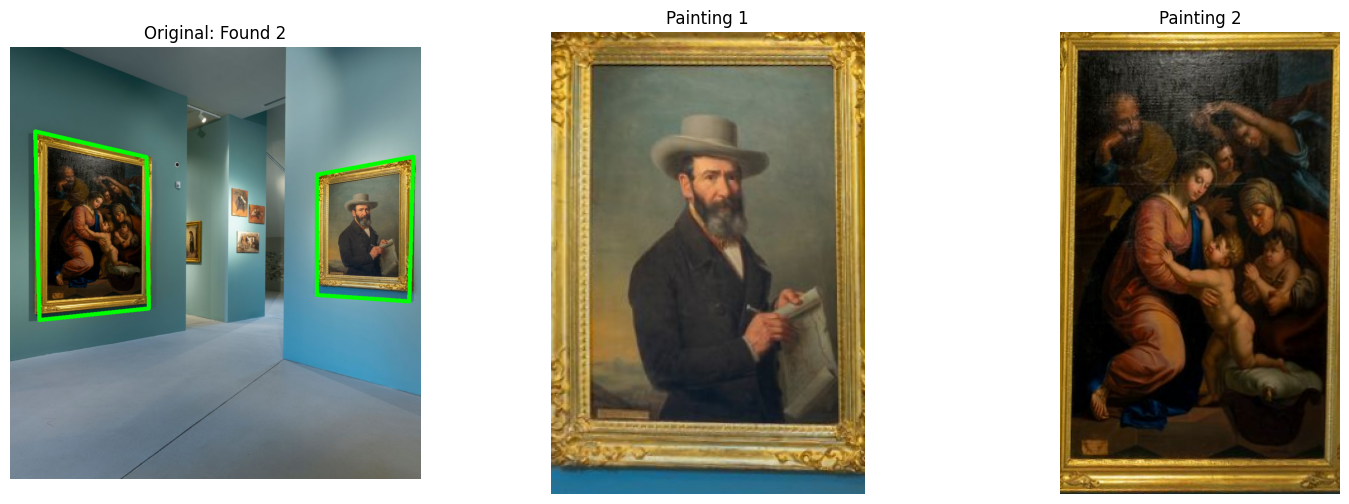

In [ ]:
"""test for v1.1, most effective method so far"""
import cv2
import matplotlib.pyplot as plt
import homography

# Replace this with the actual name of your image file
input_img = 'test_image.jpg' 

# Note: No need to manually define min_area; the algorithm automatically filters by 1% area
results, edged = homography.auto_detect_multiple_paintings(input_img)

if not results:
    print("Still not found... Check the edge detection map (edged) to see if borders are visible!")
    plt.imshow(edged, cmap='gray')
    plt.show()
else:
    print(f"🎉 Success! Detected {len(results)} painting(s)!")
    
    orig_rgb = cv2.cvtColor(cv2.imread(input_img), cv2.COLOR_BGR2RGB)
    fig = plt.figure(figsize=(6 * (len(results) + 1), 6))
    
    # Subplot for the original image with all detected boxes
    ax = fig.add_subplot(1, len(results) + 1, 1)
    ax.set_title(f"Original: Found {len(results)}")
    for res in results:
        cv2.drawContours(orig_rgb, [res["box"]], -1, (0, 255, 0), 10) 
    ax.imshow(orig_rgb)
    ax.axis('off')
    
    # Subplots for each individual detected painting
    for idx, res in enumerate(results):
        ax = fig.add_subplot(1, len(results) + 1, idx + 2)
        ax.set_title(f"Painting {idx+1}")
        warped_rgb = cv2.cvtColor(res["warped"], cv2.COLOR_BGR2RGB)
        ax.imshow(warped_rgb)
        ax.axis('off')
        
    plt.show()